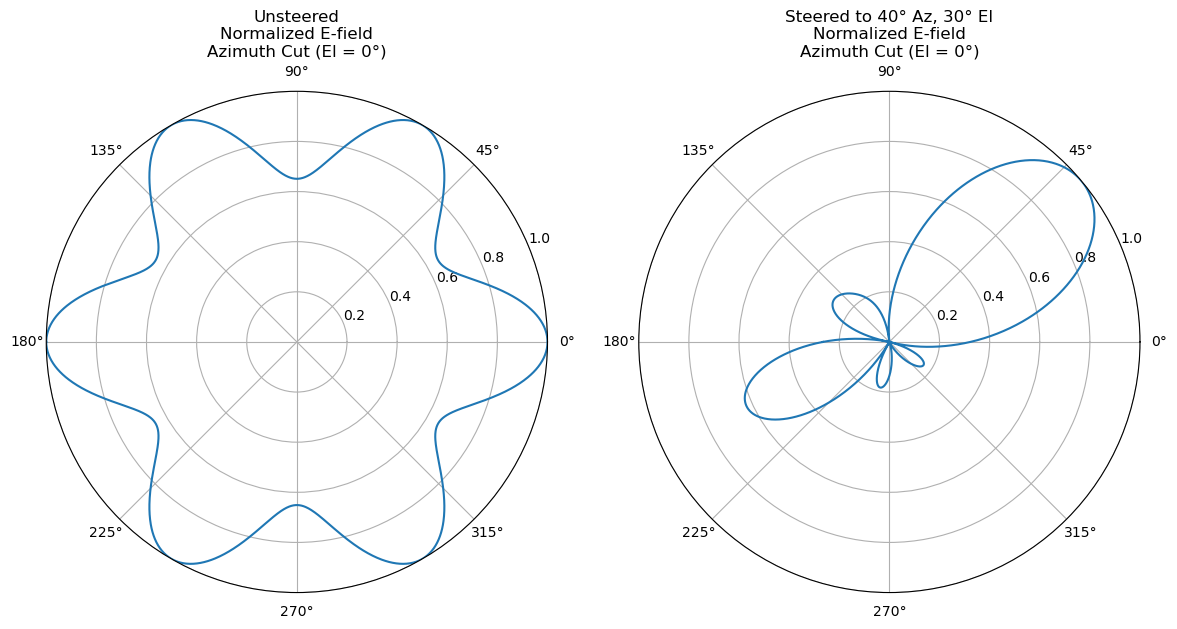

In [39]:
import numpy as np
import matplotlib.pyplot as plt

c = 3e8
f = 206.5e6
lam = c/f
k = 2*np.pi/lam

d = lam/2   

az0 = np.deg2rad(40)
el0 = np.deg2rad(30)

# 7-element hexagonal array
positions = np.array([
    [0, 0, 0],
    [ d, 0, 0],
    [ d/2,  np.sqrt(3)*d/2, 0],
    [-d/2,  np.sqrt(3)*d/2, 0],
    [-d, 0, 0],
    [-d/2, -np.sqrt(3)*d/2, 0],
    [ d/2, -np.sqrt(3)*d/2, 0]
])

N = len(positions)

az = np.linspace(-np.pi, np.pi, 1000)
el = np.deg2rad(30)


def array_factor(weights):

    AF = np.zeros(len(az), dtype=complex)

    for i in range(N):

        x, y, z = positions[i]

        phase = -k * (
            x*np.cos(el)*np.cos(az) +
            y*np.cos(el)*np.sin(az) +
            z*np.sin(el)
        )

        AF += weights[i] * np.exp(1j*phase)

    AF_mag = np.abs(AF)
    AF_mag /= np.max(AF_mag)

    return AF_mag


# Unsteered
weights_uniform = np.ones(N)
AF_unsteered = array_factor(weights_uniform)


# Steering vector
sx = np.cos(el0)*np.cos(az0)
sy = np.cos(el0)*np.sin(az0)
sz = np.sin(el0)

steering_vector = np.array([sx, sy, sz])

weights_steered = np.exp(1j * k * (positions @ steering_vector))

AF_steered = array_factor(weights_steered)


# Cartesian plot
plt.figure(figsize=(10,6))

plt.plot(np.rad2deg(az), AF_unsteered, label="Unsteered")
plt.plot(np.rad2deg(az), AF_steered, label="Steered")

plt.xlabel("Azimuth (deg)")
plt.ylabel("Array Factor")
plt.title("7-Element Hexagonal Array Beam Pattern")

plt.legend()
plt.grid()


# Polar plots
plt.figure(figsize=(6,6))
ax = plt.subplot(111, projection='polar')
ax.plot(az, AF_unsteered)
ax.set_title("Unsteered Beam (7 antennas)")

plt.figure(figsize=(6,6))
ax = plt.subplot(111, projection='polar')
ax.plot(az, AF_steered)
ax.set_title("Steered Beam (7 antennas)")

plt.show()

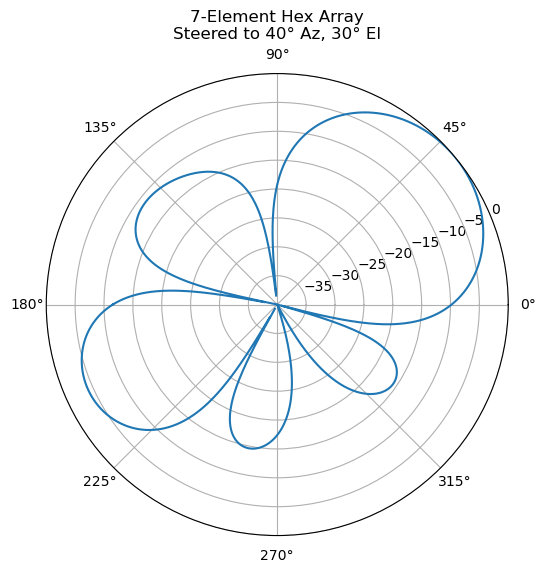

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
c = 3e8
f = 206.5e6
lam = c/f
k = 2*np.pi/lam
d = lam/2

# Hexagonal 7-element geometry
positions = np.array([
    [0, 0, 0],
    [ d, 0, 0],
    [ d/2,  np.sqrt(3)*d/2, 0],
    [-d/2,  np.sqrt(3)*d/2, 0],
    [-d, 0, 0],
    [-d/2, -np.sqrt(3)*d/2, 0],
    [ d/2, -np.sqrt(3)*d/2, 0]
])

# Steering direction (same as Simulink)
az0 = np.deg2rad(40)
el0 = np.deg2rad(30)

# Azimuth sweep
az = np.linspace(-np.pi, np.pi, 2000)
el = 0  # azimuth cut at elevation = 0

AF = []

for phi in az:
    # Observation direction unit vector
    s = np.array([
        np.cos(el)*np.cos(phi),
        np.cos(el)*np.sin(phi),
        np.sin(el)
    ])
    
    # Steering direction unit vector
    s0 = np.array([
        np.cos(el0)*np.cos(az0),
        np.cos(el0)*np.sin(az0),
        np.sin(el0)
    ])
    
    val = 0
    for r in positions:
        val += np.exp(1j*k*np.dot(r, (s - s0)))
    
    AF.append(val)

AF = np.array(AF)

P = np.abs(AF)**2
P = P/np.max(P)
P_db = 10*np.log10(P + 1e-12)

plt.figure(figsize=(6,6))
ax = plt.subplot(projection='polar')
ax.plot(az, P_db)
ax.set_title("7-Element Hex Array\nSteered to 40° Az, 30° El")
ax.set_ylim(-40, 0)
plt.show()